# Tutorial: Transform Faces with MediaPipe & GStreamer

Welcome! This notebook is a beginner-friendly guide to using the **Mediapipe GStreamer Plugins**. Even if you have never used Docker or facial tracking before, this guide will help you transform images and videos in minutes.

### What are we going to do?
Facial transformation works in three main steps:
1.  **Detection**: The AI finds 478 specific points on the face (called "Landmarks").
2.  **Mapping**: We decide which points should move. For example, to make someone smile, we move the corners of the mouth upward. This is defined in the .dfm file. See the readme for more info about this.
3.  **Warping**: A mathematical algorithm (MLS) stretches the pixels of the image to follow the moving points, creating a realistic effect.

### The Tools We Use
- **Docker**: A tool that runs our software in a "controlled box" (called a Container). This means you don't have to install complex AI libraries on your computer; they are already inside our **Docker Image**.
- **Python API**: We provide a Python function (`transform_file`) that handles everything for you automatically.

---

## 1. Getting Started with Docker

### Step A: Install Docker
Before running any code, you need **Docker Desktop** installed and running on your computer. 
- [Download for Windows](https://docs.docker.com/desktop/install/windows-install/)
- [Download for Mac](https://docs.docker.com/desktop/install/mac-install/)
- [Download for Linux](https://docs.docker.com/desktop/install/linux-install/)

### Step B: Verify Docker
Run the cell below. If you see a version number, you are ready!

In [1]:
!docker --version

Docker version 29.3.1, build c2be9cc


---

## 2. Setup: Pull the Plugins & Download Models

If you are working on a Desktop machine open the Docker Desktop and login.
Run this to download the pre-built plugins image.

In [3]:
!docker pull ducksouplab/mp_plugins:latest
!docker tag ducksouplab/mp_plugins:latest mp_plugins:latest

latest: Pulling from ducksouplab/mp_plugins

29087bcd: Pulling fs layer 
ec106686: Pulling fs layer 
31e9a28e: Pulling fs layer 
6d724f07: Pulling fs layer 
a224f9bb: Pulling fs layer 
a9925c18: Pulling fs layer 
a6053674: Pulling fs layer 
859db5aa: Pulling fs layer 
b700ef54: Pulling fs layer 
53eda25c: Pulling fs layer 
526d1ca6: Pulling fs layer 
bc9a18ed: Pulling fs layer 
d8ec02d2: Pulling fs layer 
c14fa204: Pulling fs layer 
6a266319: Pulling fs layer 
0b53180c: Pulling fs layer 
d724f07: Waiting fs layer 
9925c18: Waiting fs layer 
59db5aa: Waiting fs layer 
73babc69: Pulling fs layer 
114066a5: Pulling fs layer 
6548808b: Pulling fs layer 
700ef54: Waiting fs layer 
3eda25c: Waiting fs layer 
26d1ca6: Waiting fs layer 
c9a18ed: Waiting fs layer 
8ec02d2: Waiting fs layer 
114066a5: Waiting fs layer 
257880d: Waiting fs layer 
6548808b: Waiting fs layer 
be91f3bd: Waiting fs layer 
Digest: sha256:75b389d198707e5c9a5eb78f96bda725cfe3e31a638d8ba04c69616881659ceeDownloading  364.

### Download the MediaPipe Models
Fetch the AI model file required for face tracking.

In [1]:
import os
import sys

# Add the parent directory to the path so we can import our wrapper
sys.path.append("..")
from mozza_process import transform_file

In [ ]:
!cd .. && bash scripts/download_face_landmarker_model.sh

---

## 3. Step 1: Detect Landmarks

Let's see what the AI sees! We will take an image from the `media/inputs/` folder and draw the 478 landmarks on it.

W0000 00:00:1775204858.283743       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204858.481999      28 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204858.497986      26 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


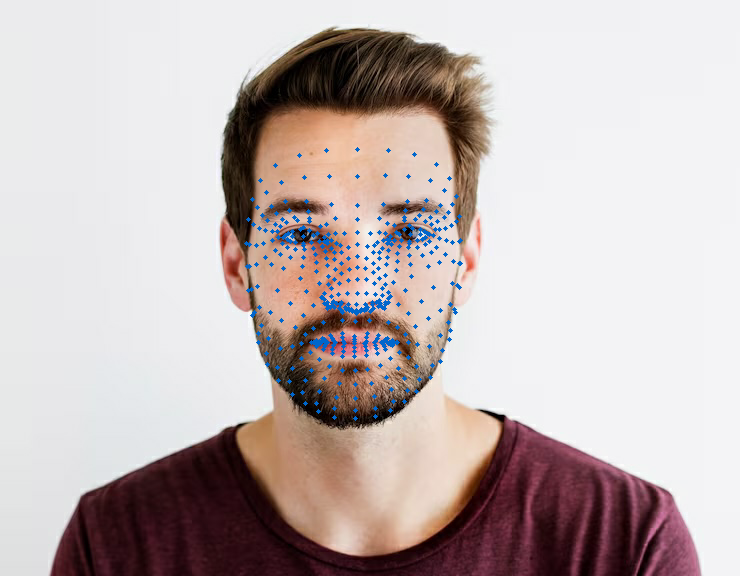

In [2]:
from IPython.display import Image, display, Video

root_dir = os.path.abspath("..")
input_img = os.path.join(root_dir, "media", "inputs", "test_image.jpg")
out_dir = os.path.join(root_dir, "media", "outputs", "mozza_mp_tutorial")
os.makedirs(out_dir, exist_ok=True)
output_img = os.path.join(out_dir, "tutorial_landmarks.png")
model_path = os.path.join(root_dir, "models", "face_landmarker.task")

# Use the Python function directly!
transform_file(
    input_path=input_img,
    output_path=output_img,
    mode="landmarks",
    model_path=model_path
)

display(Image(filename=output_img))

---

## 4. Step 2: Make Someone Smile (CPU Mode)

Apply the smile deformation using the `transform_file` function. 

**Tip:** If you don't have an NVIDIA GPU, always use `mode="cpu"`. It works on all systems.

W0000 00:00:1775204860.681633       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204860.817994      32 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204860.832730      28 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


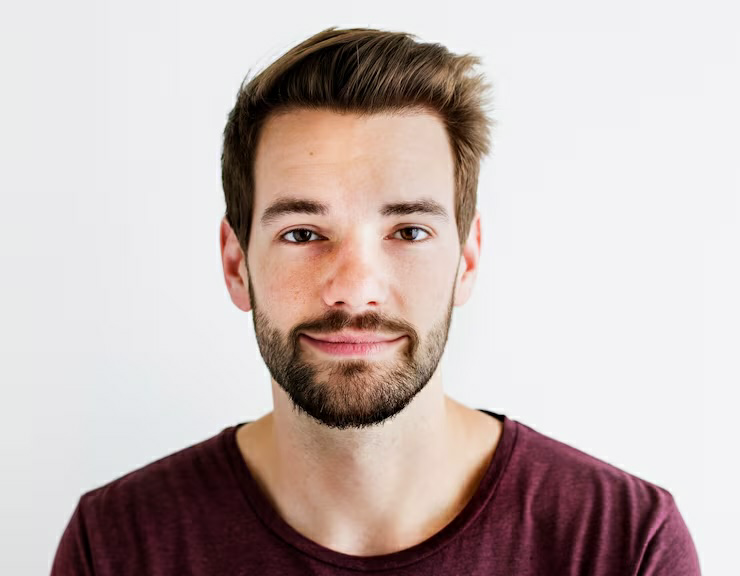

In [3]:
output_cpu = os.path.join(out_dir, "tutorial_smile_cpu.png")
deform_path = os.path.join(root_dir, "dfm", "smile.dfm")

transform_file(
    input_path=input_img,
    output_path=output_cpu,
    mode="cpu",
    deform=deform_path,
    alpha=1.2,
    warp_mode="per-group-roi",
    show_landmarks=False,
    model_path=model_path
)

display(Image(filename=output_cpu))

Or make the smile even stronger (but a bit unrealistic) by changing the alpha parameter

W0000 00:00:1775205025.368286       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775205025.499415      27 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775205025.514027      27 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


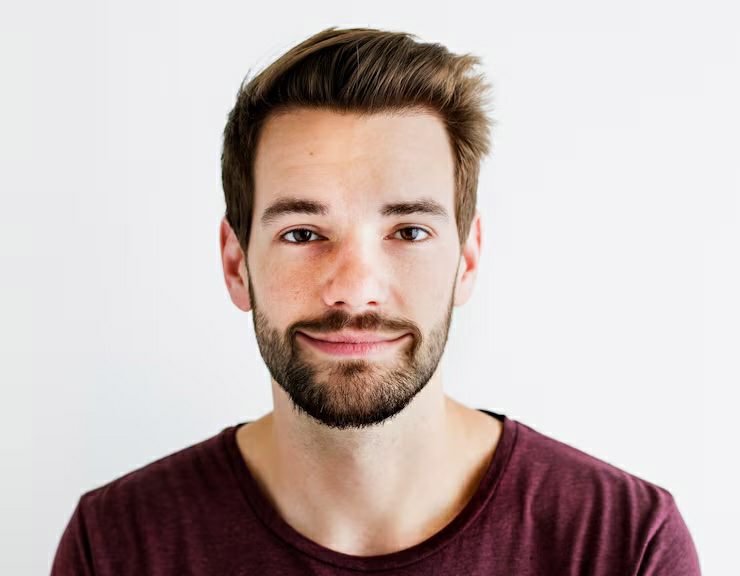

In [11]:
output_cpu = os.path.join(out_dir, "tutorial_smile_cpu.png")
deform_path = os.path.join(root_dir, "dfm", "smile.dfm")

transform_file(
    input_path=input_img,
    output_path=output_cpu,
    mode="cpu",
    deform=deform_path,
    alpha=1.6,
    warp_mode="per-group-roi",
    mls_alpha=1.3,
    mls_grid=5,
    roi_pad=35,
    show_landmarks=False,
    model_path=model_path
)

display(Image(filename=output_cpu))

Or turn the smile down by adding a negative alpha

W0000 00:00:1775204866.694215       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204866.831890      34 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204866.846683      34 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


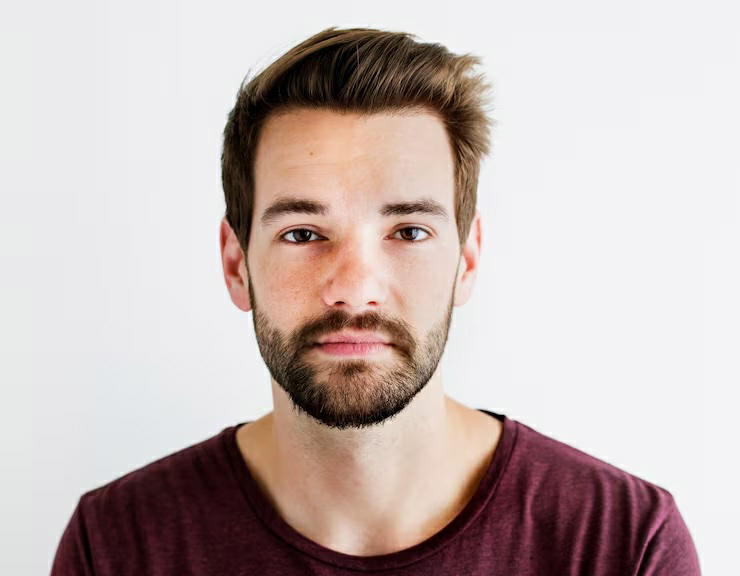

In [5]:

output_cpu = os.path.join(out_dir, "tutorial_smile_cpu.png")
deform_path = os.path.join(root_dir, "dfm", "smile.dfm")

transform_file(
    input_path=input_img,
    output_path=output_cpu,
    mode="cpu",
    deform=deform_path,
    alpha=-0.6,
    warp_mode="per-group-roi",
    show_landmarks=False,
    model_path=model_path
)

display(Image(filename=output_cpu))

Try other .dfm files

Generating: submissive_brows_v3.dfm


W0000 00:00:1775204244.105961       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204244.254834      29 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204244.271790      29 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


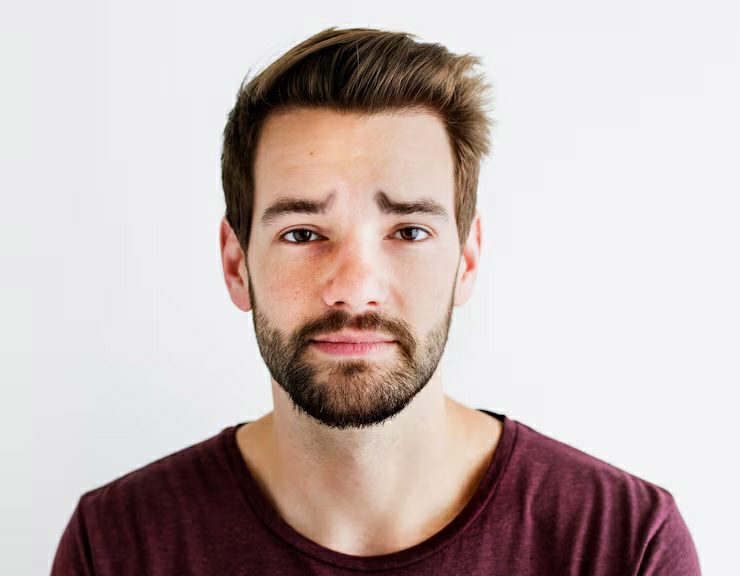

Generating: submissive_brows.dfm


W0000 00:00:1775204246.579437       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204246.712813      33 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204246.726921      33 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


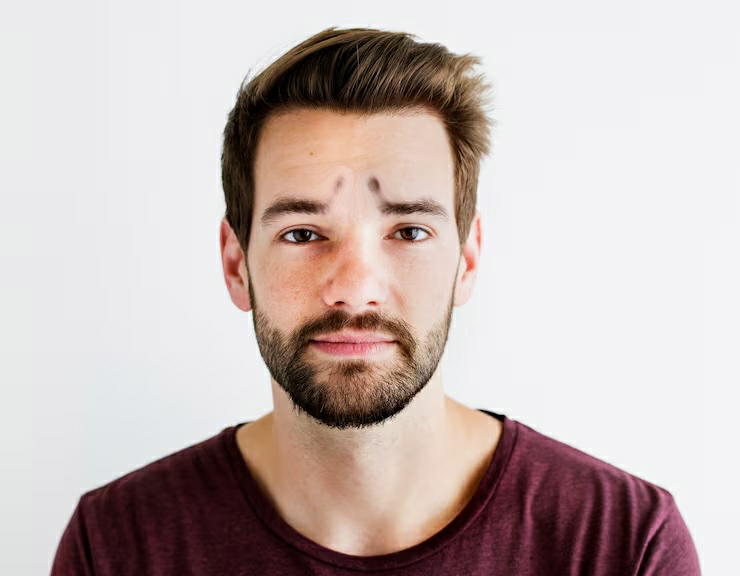

Generating: submissive_eyes_v3.dfm


W0000 00:00:1775204248.978833       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204249.126368      32 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204249.142103      32 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


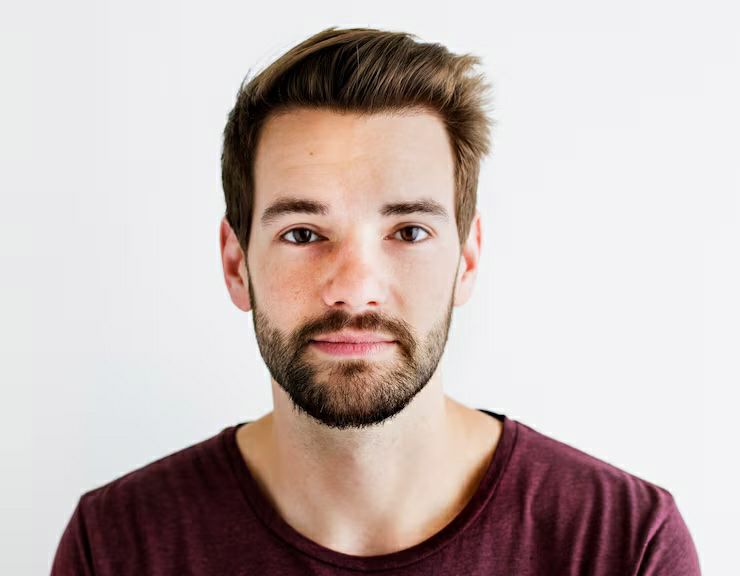

Generating: submissive_eyes.dfm


W0000 00:00:1775204251.369827       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204251.511374      35 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204251.525494      35 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


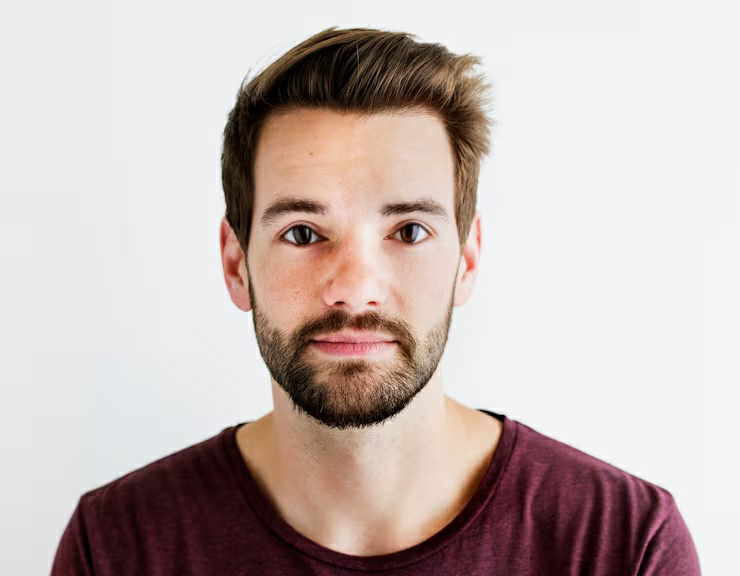

Generating: dominant_jaw_v4.dfm


W0000 00:00:1775204253.666833       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204253.799502      29 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204253.813960      29 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


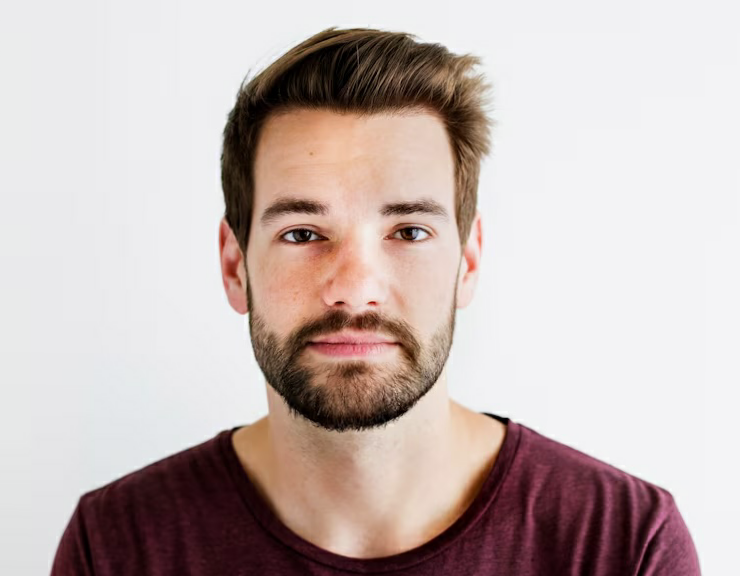

Generating: submissive_jaw_v3.dfm


W0000 00:00:1775204256.056653       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204256.191612      34 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204256.206870      34 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


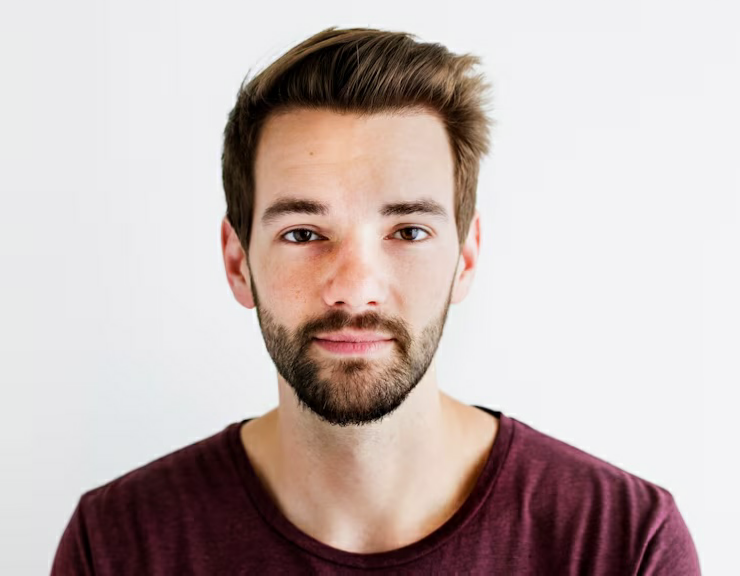

Generating: face_masculine.dfm


W0000 00:00:1775204258.449665       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204258.585078      29 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204258.599741      33 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


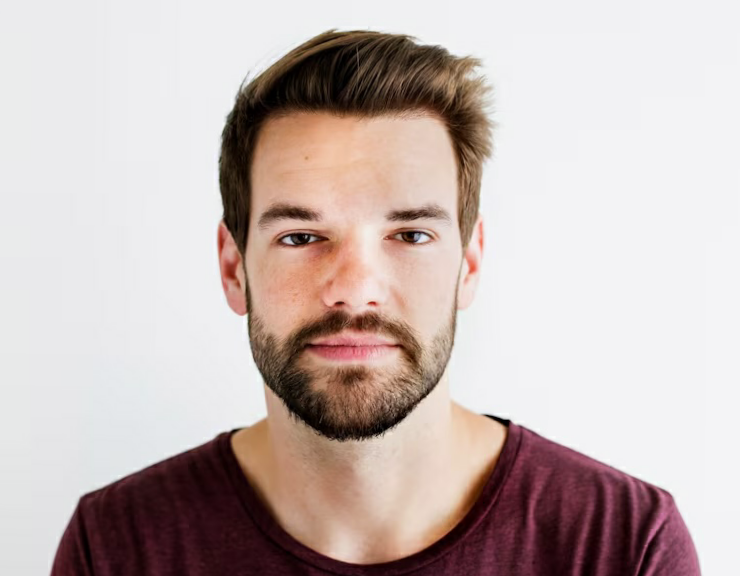

Generating: submissive_face_v3.dfm


W0000 00:00:1775204260.852371       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204260.990746      29 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204261.008820      32 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


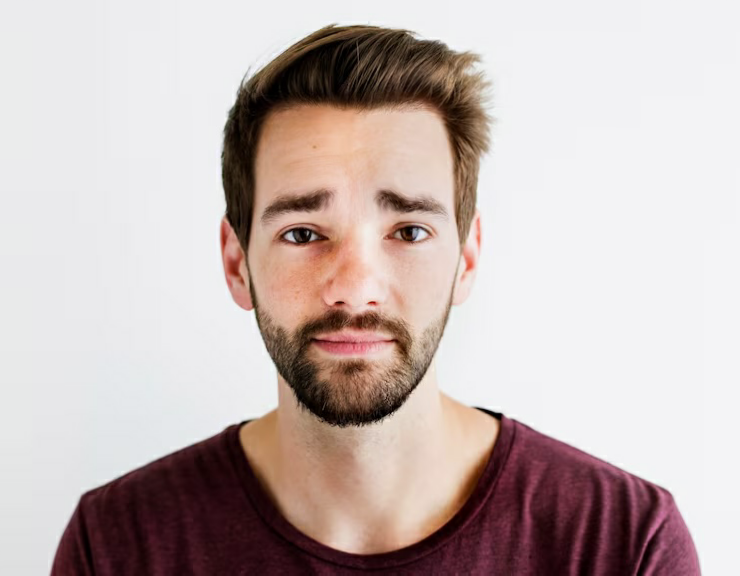

Generating: dominant_brows_soft.dfm


W0000 00:00:1775204263.309730       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204263.443229      26 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204263.458516      26 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


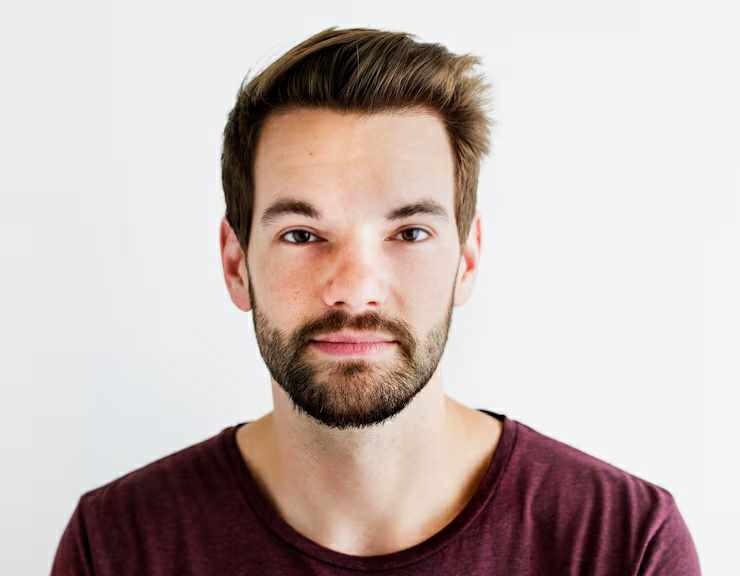

Generating: submissive_face_soft.dfm


W0000 00:00:1775204265.717698       1 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775204265.857277      25 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775204265.871444      26 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


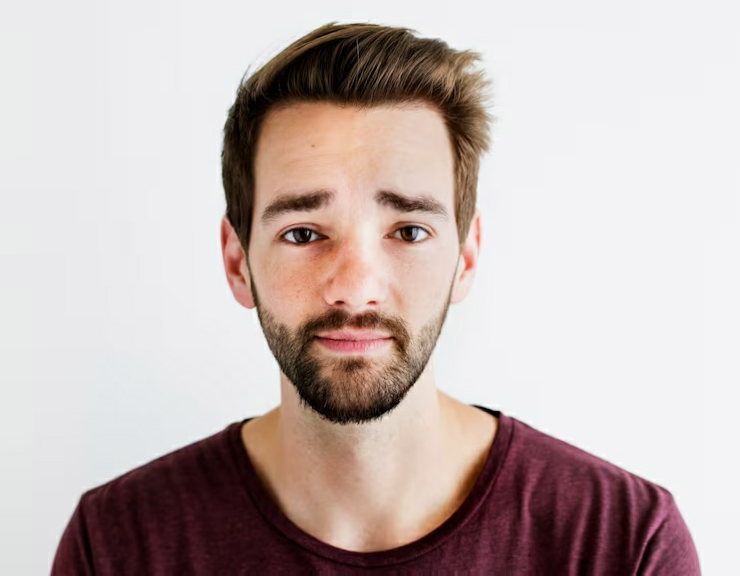


All final transformations generated in: output/


In [19]:
# --- MAIN EXECUTION LOGIC ---

dfm_dir = os.path.join(root_dir, "dfm", "morphology_selection")
output_dir = os.path.join(out_dir, "dfm")
input_img = os.path.join(root_dir, "media", "inputs", "test_image.jpg")
model_path = os.path.join(root_dir, "models", "face_landmarker.task")


if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Group 1: Precision Features (Brows and Eyes)
precision_features = ["submissive_brows_v3.dfm", "submissive_brows.dfm", "submissive_eyes_v3.dfm", "submissive_eyes.dfm"]
for dfm in precision_features:
    print(f"Generating: {dfm}")
    output_cpu = os.path.join(output_dir, dfm + ".png")
    transform_file(
        input_path=input_img, output_path=output_cpu,
        mode="cpu", deform=os.path.join(dfm_dir, dfm),
        alpha=1.0, mls_alpha=1.8, mls_grid=3, warp_mode="per-group-roi", roi_pad=30,
        show_landmarks=False, model_path=model_path
    )
    display(Image(filename=output_cpu))

# Group 2: Global Structural Shapes (Jaw and Masculinity)
global_shapes = ["dominant_jaw_v4.dfm", "submissive_jaw_v3.dfm", "face_masculine.dfm", "submissive_face_v3.dfm"]
for dfm in global_shapes:
    print(f"Generating: {dfm}")
    output_cpu = os.path.join(output_dir, dfm + ".png")
    transform_file(
        input_path=input_img, output_path=output_cpu,
        mode="cpu", deform=os.path.join(dfm_dir, dfm),
        alpha=1.0, mls_alpha=1.4, mls_grid=5, warp_mode="global", roi_pad=64,
        show_landmarks=False, model_path=model_path
    )
    display(Image(filename=output_cpu))

# Group 3: Soft Structural Variations
soft_variants = ["dominant_brows_soft.dfm", "submissive_face_soft.dfm"]
for dfm in soft_variants:
    print(f"Generating: {dfm}")
    output_cpu = os.path.join(output_dir, dfm + ".png")
    transform_file(
        input_path=input_img, output_path=output_cpu,
        mode="cpu", deform=os.path.join(dfm_dir, dfm),
        alpha=1.0, mls_alpha=1.2, mls_grid=5, 
        warp_mode="global" if "face" in dfm else "per-group-roi", roi_pad=64,
        show_landmarks=False, model_path=model_path
    )
    display(Image(filename=output_cpu))

print(f"\nAll final transformations generated in: {output_dir}")


---

## 5. Step 3: Process a Video

The function works exactly the same for videos. Let's transform a short clip.

In [9]:
input_video = os.path.join(root_dir, "media", "inputs", "dynamic_video.mp4")
output_video = os.path.join(out_dir, "tutorial_video_smile.mp4")

transform_file(
    input_path=input_video,
    output_path=output_video,
    mode="cpu",
    deform=deform_path,
    alpha=1.5,
    warp_mode="per-group-roi",
    show_landmarks=False,
    model_path=model_path
)

display(Video(output_video, width=600, embed=True))

0:00:01.391009043          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:227:gst_mozza_mp_set_property:<mozzamp0> prop:model = /models/face_landmarker.task
0:00:01.391851876          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:233:gst_mozza_mp_set_property:<mozzamp0> prop:deform/dfm = /deform/smile.dfm
0:00:01.392863001          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:237:gst_mozza_mp_set_property:<mozzamp0> prop:alpha = 1.500
0:00:01.392919459          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:242:gst_mozza_mp_set_property:<mozzamp0> prop:mls-alpha = 1.400
0:00:01.393059793          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:247:gst_mozza_mp_set_property:<mozzamp0> prop:mls-grid = 5
0:00:01.393106293          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:255:gst_mozza_mp_set_property:<mozzamp0> prop:warp-mode = per-group-roi
0:00:01.3931436

---

## 6. Advanced Customization

### A. The Parameters
- `alpha`: Intensity of the effect (1.0 = normal, 2.0 = double).
- `warp_mode`: Use `"per-group-roi"` for high-quality localized warping.
- `show_landmarks`: Set to `True` to see the dots, `False` for a realistic result.

### B. How the DFM file works
The `.dfm` file contains rules that tell landmark points where to move based on their neighbors. 

**Landmark Map:** Refer to the [MediaPipe Face Mesh Map](https://storage.googleapis.com/mediapipe-assets/documentation/visualization/face_mesh_full_landmark_connections.png) to find indices for custom rules.

---
## 7. Performance Monitoring

Both plugins have built-in timing logic. You can see how long each step takes by enabling the GStreamer Info logs and setting a `log_every` interval.

- **Detect**: Time taken to find landmarks.
- **Warp**: Time taken to apply the deformation.
- **Total**: The end-to-end latency per frame.

In [8]:
# We enable INFO logs for the 'mozza_mp' (CPU) plugin specifically
os.environ['GST_DEBUG'] = 'mozza_mp:4'

transform_file(
    input_path=input_video,
    output_path='/dev/null', # We don't need the file, just the logs
    mode='cpu', 
    log_every=30, # Print stats every 30 frames
    model_path=model_path
)

0:00:01.468132917          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:227:gst_mozza_mp_set_property:<mozzamp0> prop:model = /models/face_landmarker.task
0:00:01.469677876          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:237:gst_mozza_mp_set_property:<mozzamp0> prop:alpha = 1.000
0:00:01.469709876          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:242:gst_mozza_mp_set_property:<mozzamp0> prop:mls-alpha = 1.400
0:00:01.469825709          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:247:gst_mozza_mp_set_property:<mozzamp0> prop:mls-grid = 5
0:00:01.469848376          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:255:gst_mozza_mp_set_property:<mozzamp0> prop:warp-mode = global
0:00:01.469861334          1          1 INFO                mozza_mp gstmozzamp/gstmozzamp.cpp:261:gst_mozza_mp_set_property:<mozzamp0> prop:roi-pad = 24
0:00:01.469875959          1          1 

True